<h1 style="color:magenta;">NSL - Exercises 02 </h1>

### 12/3/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1
The 1D integral $\displaystyle I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$ was computed via Monte Carlo using two different methods:

1. sampling a uniform distribution in $[0,1]$

2. **using importance sampling** To improve the efficiency of the Monte Carlo integration, importance sampling was implemented. The integrand $f(x)$ is factorized into the product $g(x) \cdot p(x)$, where $p(x)$ is a PDF, and $g(x)$ is sampled at points distributed according to $p(x)$. To estimate the integral $I$, I chose the Taylor expansion of $f(x)$ around $x=1$ as the functional form for $p(x)$. After proper normalization, this leads to $p(x) = 2(1-x)$, therefore I sampled the function:$$g(x) = \frac{\pi}{2}\frac{\cos(\pi x/2)}{2(1-x)}$$at points $x_i$ distributed according to $p(x)$. To obtain these values of $x$, the inverse transform method was used: once the cumulative distribution function (CDF) $P(x)$ of $p(x)$ was calculated, it was inverted to find the values of $x$ by sampling $u$ values uniformly distributed in $[0, 1]$:$$P(x) = \int_0^x 2(1-t) dt = 2x - x^2 = u \implies x = 1 - \sqrt{1-u}$$In both cases, $10^5$ throws were performed, divided into $N=100$ blocks, and the uncertainties were calculated using data blocking.

The evaluations of $I$, along with their uncertainties for both methods, are shown together in the plot below. This allows for a better appreciation of the improved efficiency of importance sampling, particularly regarding the reduction of the statistical uncertainty.

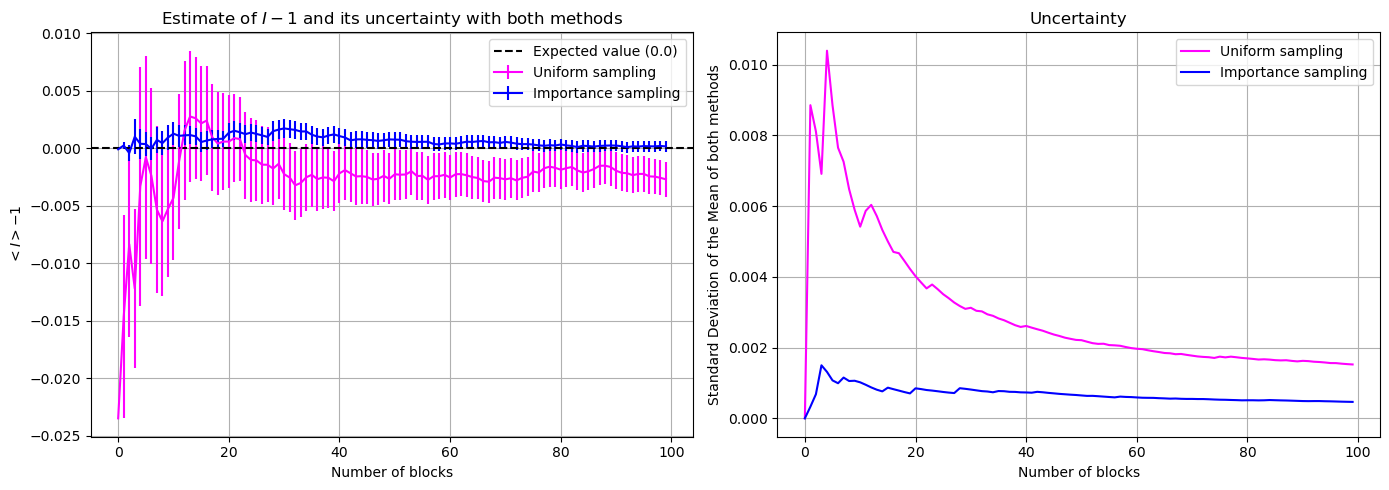

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data_unif = np.loadtxt("Exercise_1/output_ave_unif.dat")
data_imp = np.loadtxt("Exercise_1/output_ave_imp.dat")

#I unif with error bars
x_unif = data_unif[:, 0]    #Number of blocks
y_unif = data_unif[:, 1]    #<I>-1
err_unif = data_unif[:, 2]  #Standard deviation of the mean

#I imp with error bars
x_imp = data_imp[:, 0]    #Number of blocks
y_imp = data_imp[:, 1]    #<I>-1
err_imp = data_imp[:, 2]  #Standard deviation of the mean

ax1.errorbar(x_unif, y_unif, yerr=err_unif, label="Uniform sampling", color='magenta')
ax1.errorbar(x_imp, y_imp, yerr=err_imp, label="Importance sampling", color='blue')
ax1.set_xlabel("Number of blocks")
ax1.set_ylabel("$<I> - 1$")
ax1.set_title("Estimate of $I-1$ and its uncertainty with both methods")
ax1.axhline(y=0.0, color='black', linestyle='--', label='Expected value (0.0)')
ax1.legend()
ax1.grid()

#sigma unif
x_var_unif = data_unif[:, 0] #throws
y_var_unif = data_unif[:, 2] #std

#sigma imp
x_var_imp = data_imp[:, 0] #throws
y_var_imp = data_imp[:, 2] #std


ax2.plot(x_var_unif, y_var_unif, label="Uniform sampling", color='magenta')
ax2.plot(x_var_imp, y_var_imp, label="Importance sampling", color='blue')
ax2.set_xlabel("Number of blocks")
ax2.set_ylabel("Standard Deviation of the Mean of both methods")
ax2.set_title("Uncertainty")
ax2.legend()
ax2.grid()


plt.tight_layout()
plt.show()

## Ex. 2

This exercise consists of a 3D Random Walk (RW) simulation, comparing two different scenarios: a discrete motion on a cubic lattice and a motion in the continuum.
1. **Discrete Cubic Lattice**: the walker starts at the origin and moves along the principal axes with a unit step length ($a=1$). At each discrete time step, a random number $x \in [0, 3)$ is sampled to determine the direction: if $x \in [0, 1)$, the walker moves along the $x$-axis (forward if $x < 0.5$, backward otherwise), if $x \in [1, 2)$, the walker moves along the $y$-axis (forward if $x < 1.5$, backward otherwise), if $x \in [2, 3)$, the walker moves along the $z$-axis (forward if $x < 2.5$, backward otherwise). The position is updated by incrementing or decrementing the coordinates $(N_x, N_y, N_z)$. For each step $k$, the squared distance from the origin is calculated as $r_k^2 = N_x^2 + N_y^2 + N_z^2$.

2. **Continuum Random Walk**: each step has a fixed length $a=1$, but the direction is sampled uniformly over a solid angle. This is achieved by generating two independent angles: $\phi$ uniformly distributed in $[0, 2\pi]$ and $\theta$ such that its distribution accounts for the spherical surface element (sampling $\cos(\theta)$ uniformly in $[-1, 1]$). The displacement for each step is then:$$dx = \sin\theta\cos\phi, \quad dy = \sin\theta\sin\phi, \quad dz = \cos\theta$$

A total of $M = 10^4$ random walks were simulated for both cases. To evaluate the statistical uncertainties and the trend of the walk, we employed the Data Blocking method with $N = 100$ blocks. For each block, we computed the average root-mean-square distance $\sqrt{\langle |\vec{r}_i|^2 \rangle}$ as a function of the step $i \in [0, 100]$. These block averages were then used to calculate the progressive global average and its corresponding statistical error.

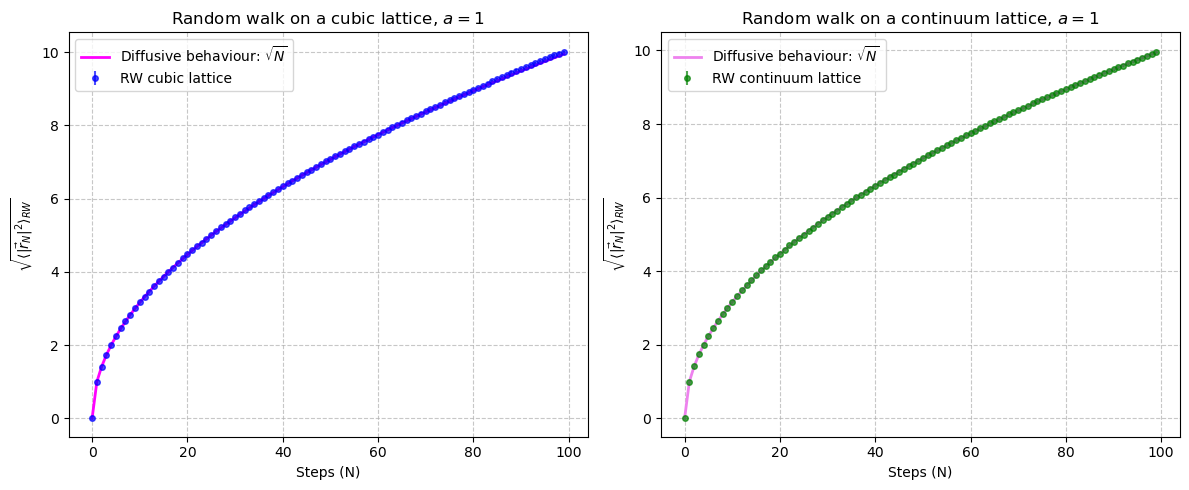

In [21]:
import matplotlib.pyplot as plt
import numpy as np

data_cubic = np.loadtxt("Exercise_2/output_cubic_lattice.dat")
x_cubic = data_cubic[:, 0]
y_cubic = data_cubic[:, 1]
err_cubic = data_cubic[:, 2]

data_continuum = np.loadtxt("Exercise_2/output_continuum_lattice.dat")
x_continuum = data_continuum[:, 0]
y_continuum = data_continuum[:, 1]
err_continuum = data_continuum[:, 2]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.errorbar(x_cubic, y_cubic, yerr=err_cubic, fmt='bo', label="RW cubic lattice", alpha=0.7, markersize=4)
plt.plot(x_cubic, np.sqrt(x_cubic), 'magenta', label=r"Diffusive behaviour: $\sqrt{N}$", linewidth=2)

plt.xlabel("Steps (N)")
plt.ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
plt.title("Random walk on a cubic lattice, $a=1$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
plt.errorbar(x_continuum, y_continuum, yerr=err_continuum, fmt='go', label="RW continuum lattice", alpha=0.7, markersize=4)
plt.plot(x_cubic, np.sqrt(x_cubic), 'violet', label=r"Diffusive behaviour: $\sqrt{N}$", linewidth=2)

plt.xlabel("Steps (N)")
plt.ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
plt.title("Random walk on a continuum lattice, $a=1$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

It can be shown that a Random Walk satisfies the diffusion equation: the results obtained effectively confirm a diffusive behavior for both cases (cubic lattice and continuum), characterized by the relationship $\langle r^2 \rangle \simeq k N$. The values of the coefficient $k$ are found to be very similar to each other and close to unity. It is important to emphasize that the equation satisfied is a stochastic differential equation, the results, therefore, represent statistical probabilities: each simulation yields a different realization, yet everything is governed by the same joint probability distribution. Furthermore, the analysis shows that the statistical error increases with the number of steps. This growth in uncertainty reflects the fact that, as the number of steps increases, the possible trajectories progressively diverge, leading to a greater dispersion of final distances relative to the origin.